# Ikibondo ML — Exploratory Data Analysis & Model Evaluation

This notebook documents the data science methodology behind the three ML models
served by `backend/apps/ml_engine/`:

| Model | Task | Artifact |
|---|---|---|
| `malnutrition_v1` | Classify visit → SAM / MAM / NORMAL | `ml/models/malnutrition_v1.pkl` |
| `growth_nn_v1` | Predict risk of WHZ deterioration from a 3-visit series | `ml/models/growth_nn_v1.pkl` |
| `vaccination_rf_v1` | Predict vaccination-dropout risk | `ml/models/vaccination_rf_v1.pkl` |

All models are trained on **synthetic data** (`ml/scripts/generate_synthetic_data.py`)
calibrated to WHO growth-standard distributions — no real child data is used in
development. Retrain with `ml/scripts/train_*.py`; evaluate with `evaluate_all.py`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path('data/processed')
MODELS = Path('models')

children = pd.read_csv(DATA / 'children_synthetic.csv')
growth = pd.read_csv(DATA / 'growth_series_synthetic.csv')
vax = pd.read_csv(DATA / 'vaccination_synthetic.csv')

print(f'children: {children.shape}, growth: {growth.shape}, vaccination: {vax.shape}')

children: (10000, 12), growth: (13433, 10), vaccination: (10000, 8)


## 1. Malnutrition dataset — EDA

The classifier's target is `nutrition_status`, derived from WHO cut-offs
(WHZ < -3 or MUAC < 11.5 cm or oedema → SAM; WHZ < -2 or MUAC < 12.5 cm → MAM).

In [2]:
children.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
child_id,10000.0,4999.50,2886.90,0.00,2499.75,4999.50,7499.25,9999.00
age_months,10000.0,29.82,17.31,0.00,15.00,30.00,45.00,59.00
sex_binary,10000.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00
camp_id,10000.0,1.98,1.41,0.00,1.00,2.00,3.00,4.00
weight_kg,10000.0,5.20,2.22,1.50,3.44,4.92,6.70,13.12
height_cm,10000.0,64.27,11.11,41.30,54.90,64.10,73.40,92.20
muac_cm,10000.0,12.65,1.47,8.70,11.40,12.90,13.90,16.70
oedema,10000.0,0.00,0.05,0.00,0.00,0.00,0.00,1.00
whz,10000.0,-1.07,1.77,-5.26,-2.60,-0.64,0.39,3.00
haz,10000.0,-0.66,1.30,-4.98,-1.59,-0.60,0.28,3.00


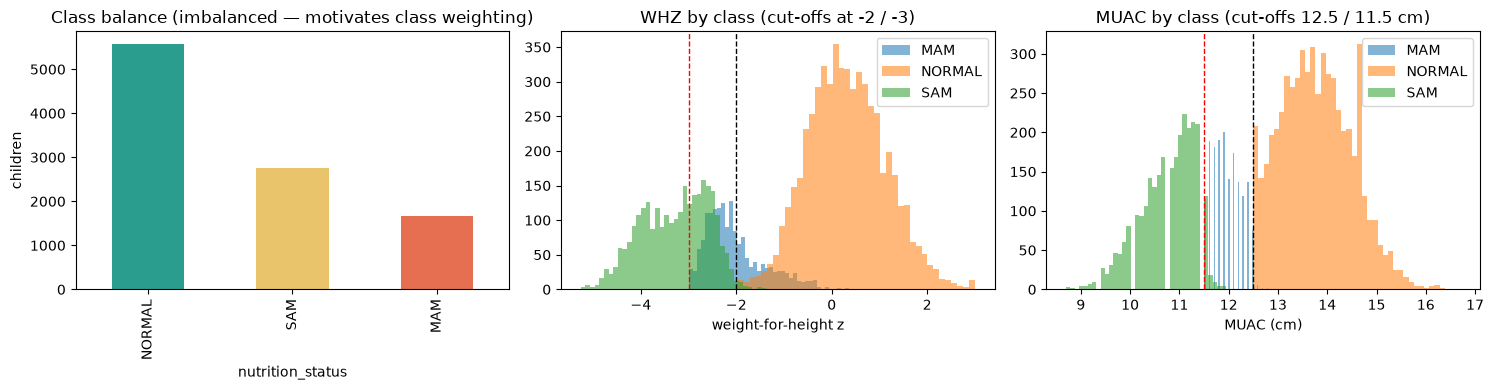

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

children['nutrition_status'].value_counts().plot.bar(ax=axes[0], color=['#2a9d8f', '#e9c46a', '#e76f51'])
axes[0].set_title('Class balance (imbalanced — motivates class weighting)')
axes[0].set_ylabel('children')

for status, grp in children.groupby('nutrition_status'):
    axes[1].hist(grp['whz'], bins=40, alpha=0.55, label=status)
axes[1].axvline(-2, ls='--', c='k', lw=1); axes[1].axvline(-3, ls='--', c='r', lw=1)
axes[1].set_title('WHZ by class (cut-offs at -2 / -3)'); axes[1].set_xlabel('weight-for-height z'); axes[1].legend()

for status, grp in children.groupby('nutrition_status'):
    axes[2].hist(grp['muac_cm'], bins=40, alpha=0.55, label=status)
axes[2].axvline(12.5, ls='--', c='k', lw=1); axes[2].axvline(11.5, ls='--', c='r', lw=1)
axes[2].set_title('MUAC by class (cut-offs 12.5 / 11.5 cm)'); axes[2].set_xlabel('MUAC (cm)'); axes[2].legend()

plt.tight_layout(); plt.show()

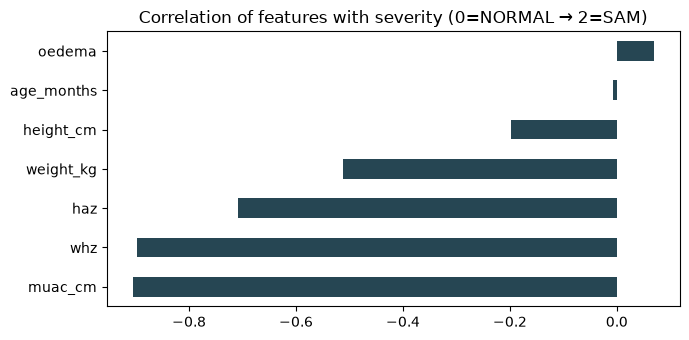

muac_cm      -0.905
whz          -0.897
haz          -0.708
weight_kg    -0.513
height_cm    -0.198
age_months   -0.007
oedema        0.069
dtype: float64

In [4]:
# Feature ↔ target association: WHZ and MUAC dominate, as clinically expected.
num_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'oedema', 'whz', 'haz']
target = children['nutrition_status'].map({'NORMAL': 0, 'MAM': 1, 'SAM': 2})
corr = children[num_cols].corrwith(target).sort_values()

corr.plot.barh(figsize=(7, 3.5), color='#264653')
plt.title('Correlation of features with severity (0=NORMAL → 2=SAM)')
plt.tight_layout(); plt.show()
corr.round(3)

## 2. Malnutrition model — held-out test metrics

Metrics come from `models/malnutrition_v1_metadata.json`, written by
`train_malnutrition.py` on a stratified held-out test split. The clinically
critical number is **SAM recall** — missing a severely malnourished child is the
worst failure mode.

In [5]:
meta = json.loads((MODELS / 'malnutrition_v1_metadata.json').read_text())
tm = pd.DataFrame(meta['test_metrics']).T
print(f"algorithm: {meta['algorithm']}")
print(f"overall accuracy: {meta['overall_accuracy']:.2%}   SAM recall: {meta['sam_recall']:.2%}")
tm

algorithm: Ensemble Decision Tree (pure numpy)
overall accuracy: 97.93%   SAM recall: 96.84%


,precision,recall,f1,support
MAM,0.9261,0.9520,0.9389,250.0
NORMAL,0.9940,0.9928,0.9934,837.0
SAM,0.9828,0.9684,0.9756,412.0


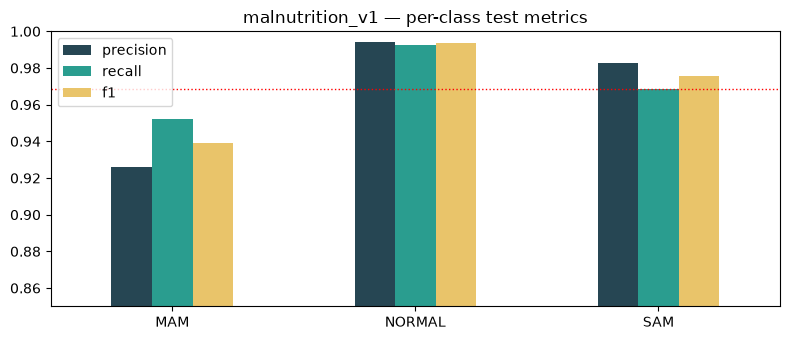

In [6]:
ax = tm[['precision', 'recall', 'f1']].plot.bar(figsize=(8, 3.5), rot=0,
        color=['#264653', '#2a9d8f', '#e9c46a'])
ax.set_ylim(0.85, 1.0); ax.set_title('malnutrition_v1 — per-class test metrics')
ax.axhline(meta['sam_recall'], ls=':', c='r', lw=1)
plt.tight_layout(); plt.show()

## 3. Growth-trajectory model

`growth_nn_v1` consumes the last **3 visits** (age, sex, weight, height, WHZ →
15 inputs) and predicts whether WHZ will deteriorate by the next visit
(`risk_flag`). This powers the "declining growth" early-warning on CHW dashboards.

In [7]:
gmeta = json.loads((MODELS / 'growth_nn_v1_metadata.json').read_text())
print(f"algorithm: {gmeta['algorithm']}")
pd.Series({k: v for k, v in gmeta.items() if k.startswith('test_')}, name='value').to_frame().round(4)

algorithm: Feedforward Neural Network (pure numpy, 15→32→16→1)


,value
test_accuracy,0.9004
test_auc,0.9602
test_precision,0.7571
test_recall,0.9303


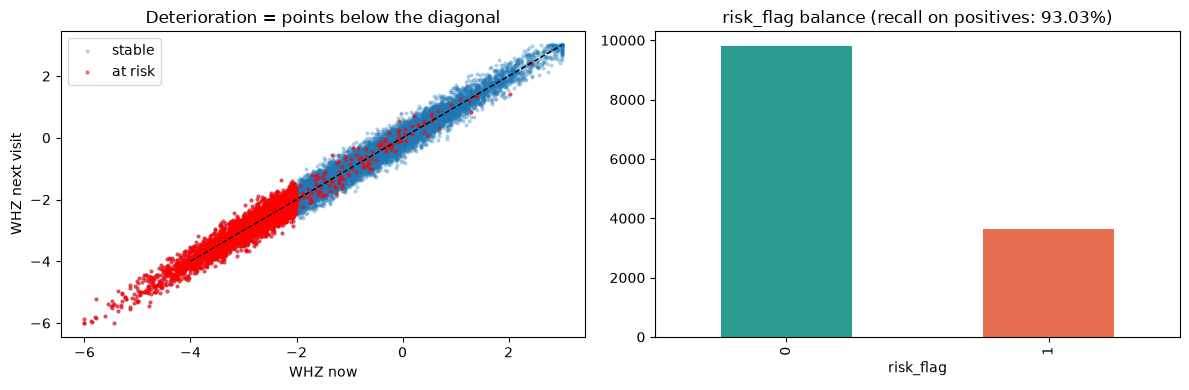

In [8]:
at_risk = growth[growth['risk_flag'] == 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(growth['whz'], growth['whz_next'], s=4, alpha=0.25, label='stable')
axes[0].scatter(at_risk['whz'], at_risk['whz_next'], s=4, alpha=0.5, c='r', label='at risk')
axes[0].plot([-4, 3], [-4, 3], 'k--', lw=1)
axes[0].set_xlabel('WHZ now'); axes[0].set_ylabel('WHZ next visit')
axes[0].set_title('Deterioration = points below the diagonal'); axes[0].legend()

growth['risk_flag'].value_counts().plot.bar(ax=axes[1], color=['#2a9d8f', '#e76f51'])
axes[1].set_title(f"risk_flag balance (recall on positives: {gmeta['test_recall']:.2%})")
plt.tight_layout(); plt.show()

## 4. Vaccination-dropout model

`vaccination_rf_v1` predicts the probability a scheduled dose will be missed,
mapped to LOW / MEDIUM / HIGH tiers used by the nurse "Remind overdue" workflow.

**Honest limitation:** ROC-AUC ≈ 0.61 — behavioural dropout is far harder to
predict from these features than anthropometry-based status. The tiers are used
for outreach *prioritisation*, never for clinical decisions.

In [9]:
vmeta = json.loads((MODELS / 'vaccination_rf_v1_metadata.json').read_text())
print(f"algorithm: {vmeta['algorithm']}")
print(f"risk tiers: {vmeta['risk_tiers']}")
pd.Series({k: v for k, v in vmeta.items() if k.startswith('test_')}, name='value').to_frame().round(4)

algorithm: Ensemble Decision Tree (pure numpy, 7 trees, balanced weights)
risk tiers: {'LOW': '< 0.35', 'MEDIUM': '0.35-0.65', 'HIGH': '> 0.65'}


,value
test_roc_auc,0.6110
test_accuracy,0.6625
test_precision,0.4815
test_recall,0.1955


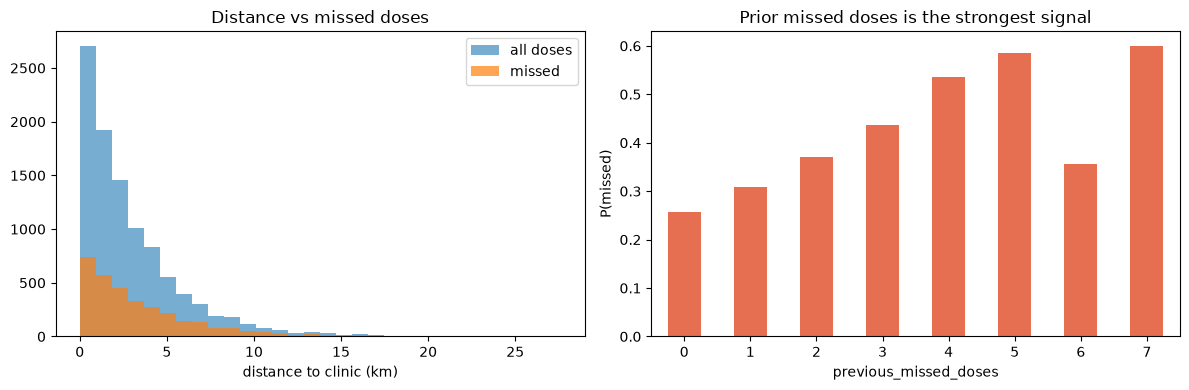

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

missed = vax[vax['missed'] == 1]
axes[0].hist(vax['distance_km'], bins=30, alpha=0.6, label='all doses')
axes[0].hist(missed['distance_km'], bins=30, alpha=0.7, label='missed')
axes[0].set_xlabel('distance to clinic (km)'); axes[0].set_title('Distance vs missed doses'); axes[0].legend()

rate = vax.groupby('previous_missed_doses')['missed'].mean()
rate.plot.bar(ax=axes[1], color='#e76f51', rot=0)
axes[1].set_ylabel('P(missed)'); axes[1].set_title('Prior missed doses is the strongest signal')
plt.tight_layout(); plt.show()

## 5. Conclusions

- **malnutrition_v1** is deployment-ready on synthetic data: 97.9% accuracy with
  96.8% SAM recall; the serving path adds SHAP-style per-feature explanations.
- **growth_nn_v1** reaches AUC 0.96 with 93% recall on deterioration — suitable
  as an early-warning flag with nurse review.
- **vaccination_rf_v1** is a weak learner (AUC 0.61) kept deliberately in an
  advisory role for SMS-reminder prioritisation.
- Next steps: retrain on real (consented, de-identified) registry data,
  calibrate probabilities, and monitor drift via `MLPredictionLog`.